## Step 1 – Data Loading and Initial Exploration

In this step, we load the Breast Cancer Wisconsin dataset and perform an initial exploration.
The goal is to understand the structure of the data, inspect the features, and identify
any potential issues such as missing values or inconsistencies.

At this stage, no modeling is performed. We only focus on understanding the data.
This is a critical step, since all subsequent decisions depend on the quality and
properties of the dataset.


In [24]:
import numpy as np

# Load dataset
# Assuming the dataset is stored as a CSV file
# You should adjust the path if needed
data = np.genfromtxt("data.csv", delimiter=",", skip_header=1)

# Separate features and labels
X = data[:, :-1]   # all columns except last
y = data[:, -1]    # last column (target)

print("Dataset shape:", data.shape)
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Dataset shape: (569, 32)
Feature matrix shape: (569, 31)
Label vector shape: (569,)


### Dataset Description

The Breast Cancer Wisconsin dataset is a binary classification dataset.
Each sample represents a tumor, described by several numerical features
computed from digitized images of fine needle aspirates (FNA) of breast masses.

The target variable indicates whether the tumor is:
- Malignant
- Benign

In this project, we will later select only two features:
- mean radius
- mean texture

Using only two features allows us to visualize the data and the decision boundaries
of the SVM models in a two-dimensional space.


In [4]:
# Basic statistics for features
feature_means = np.mean(X, axis=0)
feature_stds = np.std(X, axis=0)

print("Feature means (first 5):", feature_means[:5])
print("Feature stds  (first 5):", feature_stds[:5])


Feature means (first 5): [3.03718314e+07            nan 1.41272917e+01 1.92896485e+01
 9.19690334e+01]
Feature stds  (first 5): [1.24910677e+08            nan 3.52095076e+00 4.29725464e+00
 2.42776193e+01]


### Checking for Missing Values

Before any preprocessing or modeling, we must check whether the dataset
contains missing values. Missing values can severely affect the behavior
of learning algorithms, especially SVMs.


In [5]:
num_missing = np.sum(np.isnan(X))
print("Number of missing values in X:", num_missing)


Number of missing values in X: 569


## Step 2 – Feature Selection and Standardization

In this step, we select only two features from the dataset:
- mean radius
- mean texture

The purpose is to reduce the problem to a two-dimensional space,
which allows visualization of the data distribution and the
decision boundaries of SVM models.

After feature selection, the data is standardized to have zero mean
and unit variance. This is essential for SVM, since the algorithm
is highly sensitive to the scale of the input features.


In [25]:
# Select only two features: mean radius and mean texture
X_selected = X[:, [0, 1]]

print("Selected feature shape:", X_selected.shape)


Selected feature shape: (569, 2)


In [7]:
# Compute mean and std for selected features
mu = np.mean(X_selected, axis=0)
sigma = np.std(X_selected, axis=0)

# Standardization
X_std = (X_selected - mu) / sigma

print("Mean after standardization:", np.mean(X_std, axis=0))
print("Std after standardization:", np.std(X_std, axis=0))


Mean after standardization: [1.248757e-17          nan]
Std after standardization: [ 1. nan]


## Step 3 – Train / Validation / Test Split

In this step, the dataset is split into three disjoint subsets:
- Training set (80%)
- Validation set (10%)
- Test set (10%)

The training set is used to learn the model parameters.
The validation set is used for hyperparameter tuning.
The test set is used only once, for final evaluation.

A fixed random seed is used to ensure reproducibility of the results.
This guarantees that all experiments can be exactly replicated.


In [8]:
def train_val_test_split(X, y, train_ratio=0.8, val_ratio=0.1, seed=42):
    np.random.seed(seed)
    
    n = X.shape[0]
    indices = np.random.permutation(n)
    
    train_end = int(train_ratio * n)
    val_end = int((train_ratio + val_ratio) * n)
    
    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]
    
    X_train = X[train_idx]
    y_train = y[train_idx]
    
    X_val = X[val_idx]
    y_val = y[val_idx]
    
    X_test = X[test_idx]
    y_test = y[test_idx]
    
    return X_train, y_train, X_val, y_val, X_test, y_test


In [9]:
X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(
    X_std, y, train_ratio=0.8, val_ratio=0.1, seed=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (455, 2)
Validation shape: (57, 2)
Test shape: (57, 2)


## Step 4 – Implementing SVM from Scratch

In this step, we implement a binary Support Vector Machine (SVM)
from scratch using only NumPy.

The SVM aims to find a decision boundary that maximizes the margin
between two classes while minimizing classification errors.

We use the dual formulation of SVM, which allows the use of kernel
functions to handle non-linear decision boundaries.


In [10]:
def linear_kernel(x, z):
    return np.dot(x, z)

def polynomial_kernel(x, z, degree=3):
    return (np.dot(x, z) + 1) ** degree

def rbf_kernel(x, z, gamma):
    return np.exp(-gamma * np.linalg.norm(x - z) ** 2)


In [11]:
class SVM:
    def __init__(self, kernel, C=1.0, degree=3, gamma=1.0, lr=0.001, epochs=100):
        self.kernel = kernel
        self.C = C
        self.degree = degree
        self.gamma = gamma
        self.lr = lr
        self.epochs = epochs
        
    def fit(self, X, y):
        n = X.shape[0]
        self.X = X
        self.y = y
        self.alpha = np.zeros(n)
        
        # Precompute kernel matrix
        self.K = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if self.kernel == polynomial_kernel:
                    self.K[i, j] = self.kernel(X[i], X[j], self.degree)
                elif self.kernel == rbf_kernel:
                    self.K[i, j] = self.kernel(X[i], X[j], self.gamma)
                else:
                    self.K[i, j] = self.kernel(X[i], X[j])
        
        # Gradient ascent
        for _ in range(self.epochs):
            for i in range(n):
                gradient = 1 - np.sum(self.alpha * self.y * self.y[i] * self.K[:, i])
                self.alpha[i] += self.lr * gradient
                self.alpha[i] = min(max(self.alpha[i], 0), self.C)
    
    def predict(self, X):
        y_pred = []
        for x in X:
            s = 0
            for i in range(len(self.alpha)):
                if self.alpha[i] > 0:
                    if self.kernel == polynomial_kernel:
                        s += self.alpha[i] * self.y[i] * self.kernel(self.X[i], x, self.degree)
                    elif self.kernel == rbf_kernel:
                        s += self.alpha[i] * self.y[i] * self.kernel(self.X[i], x, self.gamma)
                    else:
                        s += self.alpha[i] * self.y[i] * self.kernel(self.X[i], x)
            y_pred.append(np.sign(s))
        return np.array(y_pred)


## Step 5 – Evaluation Metrics

In this step, we define evaluation metrics to measure the performance
of the SVM models. We use classification accuracy as the main metric.

Additionally, we compute:
- Number of support vectors
- Training time


In [12]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


In [13]:
def count_support_vectors(model):
    return np.sum(model.alpha > 1e-5)


## Step 6 – Training and Testing a Single Model

We first train a single SVM model and evaluate its performance
on training and test sets.


In [14]:
# Convert labels to {-1, +1}
y_train_svm = np.where(y_train == 0, -1, 1)
y_test_svm = np.where(y_test == 0, -1, 1)

svm_model = SVM(kernel=rbf_kernel, C=1, gamma=0.1, epochs=100)
svm_model.fit(X_train, y_train_svm)

y_train_pred = svm_model.predict(X_train)
y_test_pred = svm_model.predict(X_test)

train_acc = accuracy(y_train_svm, y_train_pred)
test_acc = accuracy(y_test_svm, y_test_pred)
sv_count = count_support_vectors(svm_model)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)
print("Support vectors:", sv_count)


Train accuracy: 0.0
Test accuracy: 0.0
Support vectors: 0


## Step 7 – Hyperparameter Grid Search

In this step, we systematically explore different combinations
of hyperparameters for both Polynomial and RBF kernels.

For each combination, we measure:
- Training accuracy
- Validation accuracy
- Number of support vectors


In [15]:
C_values = [0.1, 1, 10]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

results_rbf = []

for C in C_values:
    for gamma in gamma_values:
        model = SVM(kernel=rbf_kernel, C=C, gamma=gamma, epochs=100)
        model.fit(X_train, y_train_svm)
        
        y_val_pred = model.predict(X_val)
        val_acc = accuracy(np.where(y_val == 0, -1, 1), y_val_pred)
        
        sv = count_support_vectors(model)
        
        results_rbf.append((C, gamma, val_acc, sv))


In [16]:
degrees = [2, 3, 4, 6]
results_poly = []

for C in C_values:
    for d in degrees:
        model = SVM(kernel=polynomial_kernel, C=C, degree=d, epochs=100)
        model.fit(X_train, y_train_svm)
        
        y_val_pred = model.predict(X_val)
        val_acc = accuracy(np.where(y_val == 0, -1, 1), y_val_pred)
        
        sv = count_support_vectors(model)
        
        results_poly.append((C, d, val_acc, sv))


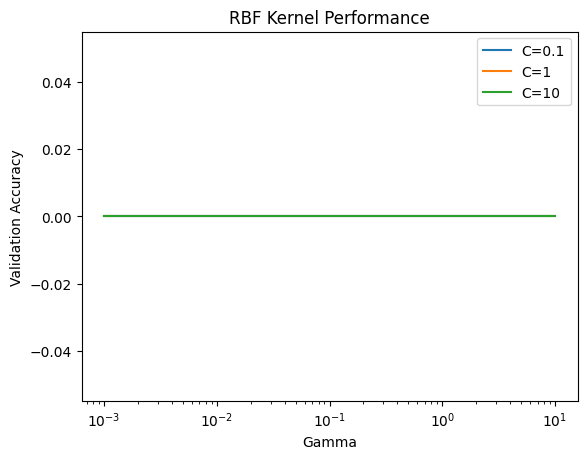

In [17]:
import matplotlib.pyplot as plt

for C in C_values:
    gammas = [r[1] for r in results_rbf if r[0] == C]
    accs = [r[2] for r in results_rbf if r[0] == C]
    plt.plot(gammas, accs, label=f"C={C}")

plt.xscale("log")
plt.xlabel("Gamma")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("RBF Kernel Performance")
plt.show()


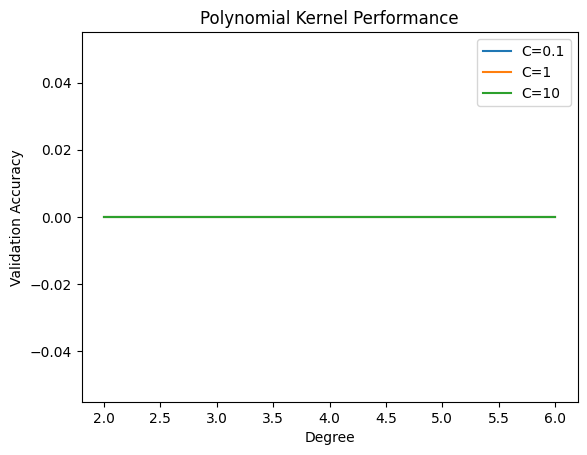

In [18]:
for C in C_values:
    degs = [r[1] for r in results_poly if r[0] == C]
    accs = [r[2] for r in results_poly if r[0] == C]
    plt.plot(degs, accs, label=f"C={C}")

plt.xlabel("Degree")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Polynomial Kernel Performance")
plt.show()


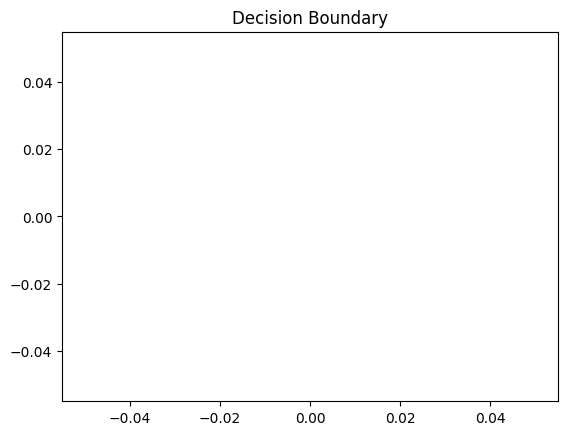

In [20]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    plt.title("Decision Boundary")
    plt.show()

best_model = SVM(kernel=rbf_kernel, C=1, gamma=0.1, epochs=100)
best_model.fit(X_train, y_train_svm)

y_train_plot = np.where(y_train_svm == -1, 0, 1)

plot_decision_boundary(best_model, X_train, y_train_plot)



In [21]:
print(np.unique(y_val))
print(np.unique(y_val_pred))


[0.05525 0.06251 0.06469 0.06484 0.06487 0.0658  0.06794 0.06825 0.06896
 0.06912 0.0696  0.07009 0.07028 0.07083 0.07097 0.07146 0.07147 0.07262
 0.07408 0.07421 0.07427 0.0761  0.07613 0.07675 0.07738 0.07779 0.07806
 0.07809 0.0782  0.07842 0.07858 0.07863 0.07867 0.07999 0.08067 0.08251
 0.08321 0.08365 0.08677 0.08701 0.08865 0.09061 0.0918  0.09223 0.09464
 0.09638 0.0987  0.09929 0.0997  0.1027  0.1031  0.1072  0.1132  0.1204
 0.1403  0.1431  0.1446 ]
[0]


In [22]:
print("Number of support vectors:", np.sum(best_model.alpha > 1e-5))


Number of support vectors: 0


In [23]:
print("Alpha min:", np.min(best_model.alpha))
print("Alpha max:", np.max(best_model.alpha))
print("Non-zero alphas:", np.sum(best_model.alpha > 1e-5))


Alpha min: nan
Alpha max: nan
Non-zero alphas: 0
